In [5]:
import pandas as pd
import glob
import seaborn as sns
import re
import os
import matplotlib.pyplot as plt




def gather_results(results_folder,
                   epochs = None, classes = None, percents = None, runs = None,
                   base = True, retrain = True):

    # gather subdirectories
    all_subdirs = []
    for root, dirs, files in os.walk(results_folder):
        for d in dirs:
            all_subdirs.append(os.path.join(root, d))
            
    if epochs is not None:
        epoch_dirs = [d for d in all_subdirs if "epoch" in d]
        pattern = rf"_({'|'.join(map(str, epochs))})$"
        dirs_to_remove = [d for d in epoch_dirs if not re.search(pattern, d)]
        all_subdirs = [d for d in all_subdirs if d not in dirs_to_remove]

    if not base:
        all_subdirs = [d for d in all_subdirs if "base" not in d]

    if not retrain:
        all_subdirs = [d for d in all_subdirs if "retrain" not in d]

    # gather results
    all_results = []
    for subdir in all_subdirs:

        # grab json files in this subdir
        file_paths = glob.glob(os.path.join(subdir, "*.json"))
        
        # remove the config json if it exists
        file_paths = [f for f in file_paths if "config" not in f]
        
        # remove any unnecessary classes, percents, runs
        if classes is not None:
            pattern = rf"class_({'|'.join(map(str, classes))})"
            file_paths = [f for f in file_paths if re.search(pattern, f)]

        if percents is not None:
            pattern = rf"percent_({'|'.join(map(str, percents))})"
            file_paths = [f for f in file_paths if re.search(pattern, f)]

        if runs is not None:
            pattern = rf"run_({'|'.join(map(str, runs))})"
            file_paths = [f for f in file_paths if re.search(pattern, f)]
        
        # Check if anything is left AFTER filtering
        if not file_paths:
            continue
        
        # add jsons for these file paths
        all_jsons = []
        for f in file_paths:
            data = pd.read_json(f, typ='series')
            
            # add class if none
            match = re.search(r'class_(\d+)', f)
            if match:
                data['class'] = int(match.group(1))
            else:
                data['class'] = -99  # default value if no match

            # add percent if none
            match = re.search(r'percent_(\d+)', f)
            if match:
                data['percent'] = int(match.group(1))
            else:
                data['percent'] = -99  # default value if no match

            # add epoch if none
            match = re.search(r'base', f)
            if match:
                data['epoch'] = -99

            match = re.search(r'retrain', f)
            if match:
                data['epoch'] = -98

            # add run if none
            match = re.search(r'run_(\d+)', f)
            if match:
                data['run'] = int(match.group(1))
            else:
                data['run'] = -99  # default value if no match

            all_jsons.append(data)

        # and concat and append to main df
        df = pd.concat(all_jsons, axis=1).T
        all_results.append(df)
    if not all_results:
        raise ValueError("No results - check settings")
    final_df = pd.concat(all_results, axis=0)


    if "MIA" in final_df.columns:

        expanded_MIA = pd.json_normalize(final_df['MIA'])

        # json_normalize resets the index, so you MUST align it with your original dataframe
        expanded_MIA.index = final_df.index

        # Optional prefixing
        expanded_MIA = expanded_MIA.add_prefix('MIA_')

        # 2. Drop the original nested column and concatenate
        final_df = pd.concat([final_df.drop('MIA', axis=1), expanded_MIA], axis=1)

    return final_df


def results_scatterplot(final_df, x_metric, y_metric, 
                        color_by = "epoch", 
                        base_color = "black", retain_color = "purple"
                        ):

    
    # set up colors
    unique_epochs = sorted(final_df[color_by].unique())
    colors_list = plt.cm.tab20.colors
    palette_dict = {}
    color_idx = 0
    for epoch in unique_epochs:
        if epoch == -99:
            palette_dict[epoch] = base_color
        elif epoch == -98:
            palette_dict[epoch] = retain_color
        else:
            # Use modulo to cycle through tab20 if you have more than 20 epochs
            palette_dict[epoch] = colors_list[color_idx % len(colors_list)]
            color_idx += 1

    # plot
    plt.clf()
    sns.set_style("whitegrid")
    sns.scatterplot(
        data=final_df, 
        x=x_metric, 
        y=y_metric, 
        hue=color_by, 
        palette=palette_dict,  # Use the mapping dictionary here
        alpha=0.7,
        edgecolor=None
    )
    # Formatting
    plt.title(f"{x_metric} vs. {y_metric}")
    plt.xlabel(x_metric.capitalize().replace("_", " "))
    plt.ylabel(y_metric.capitalize().replace("_", " "))
    handles, labels = plt.gca().get_legend_handles_labels()
    # 2. Replace -99 (or -99.0) with "base" in the labels list
    new_labels = ["base" if label == "-99" or label == "-99.0" else "retrain" if label == "-98" or label == "-98.0" else label for label in labels]
    plt.legend(title=color_by.capitalize(), handles = handles, labels = new_labels, bbox_to_anchor=(1.05, 1), loc='upper left')
    # plt.xlim(.6, .95)
    # plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

In [6]:
results = gather_results("results/seed_3013")
results

,forget_loss,forget_acc,forget_entr,forget_m_entr,retain_loss,retain_acc,retain_entr,retain_m_entr,test_loss,test_acc,...,MIA_confidence_no_class.retain_test_member,MIA_confidence_no_class.forget_non_member,MIA_entropy_class.retain_test_member,MIA_entropy_class.forget_non_member,MIA_entropy_no_class.retain_test_member,MIA_entropy_no_class.forget_non_member,MIA_m_entropy_class.retain_test_member,MIA_m_entropy_class.forget_non_member,MIA_m_entropy_no_class.retain_test_member,MIA_m_entropy_no_class.forget_non_member
0,3.193789,40.82,6.053879,3.09406,0.157524,96.493333,0.408697,0.13083,0.568773,86.09,...,0.957778,0.9968,0.929667,0.0,0.960889,0.9756,0.941556,0.0,0.961333,0.9912
0,3.5056,2.4,2.684969,3.572105,0.126756,96.466667,0.220182,0.116376,0.62469,82.5,...,0.950000,1.0000,0.918444,0.0,0.880000,0.9944,0.930444,0.0,0.945889,1.0000
0,3.398075,1.66,2.922066,3.434837,0.144474,96.357778,0.294609,0.122814,0.609817,82.5,...,0.941000,1.0000,0.907667,0.0,0.949556,0.9866,0.948889,0.0,0.952556,1.0000
0,2.913513,7.96,3.675066,2.891044,0.130647,96.731111,0.290377,0.10422,0.547081,83.04,...,0.939333,0.9998,0.928222,0.0,0.961444,0.9734,0.938111,0.0,0.953556,0.9992
0,3.853114,0.94,2.573212,3.944275,0.131511,96.415556,0.229721,0.118789,0.657501,82.37,...,0.951778,1.0000,0.908111,0.0,0.882556,0.9950,0.931333,0.0,0.947667,1.0000
0,3.066966,20.32,5.660964,2.966085,0.164133,96.462222,0.443401,0.130093,0.55484,84.42,...,0.965444,0.9944,0.964667,0.0,0.960667,0.9740,0.952000,0.0,0.957222,0.9952
0,3.425175,0.42,2.656157,3.836656,0.11839,96.517778,0.208623,0.109976,0.614699,82.7,...,0.940111,1.0000,0.923444,0.0,0.911778,0.9780,0.931111,0.0,0.930000,1.0000
0,3.527075,0.36,2.759744,3.928265,0.147881,95.833333,0.300826,0.127296,0.629539,82.03,...,0.945667,1.0000,0.896111,0.0,0.919556,0.9758,0.939667,0.0,0.951111,0.9998
0,3.128382,2.74,3.396338,3.337788,0.137836,96.491111,0.312028,0.1127,0.573497,82.45,...,0.947667,0.9998,0.934556,0.0,0.916333,0.9890,0.947667,0.0,0.947000,0.9996
0,3.971412,0.26,2.483314,4.548918,0.146496,95.633333,0.252868,0.134863,0.694195,81.92,...,0.933556,1.0000,0.885667,0.0,0.907889,0.9448,0.924889,0.0,0.928333,1.0000


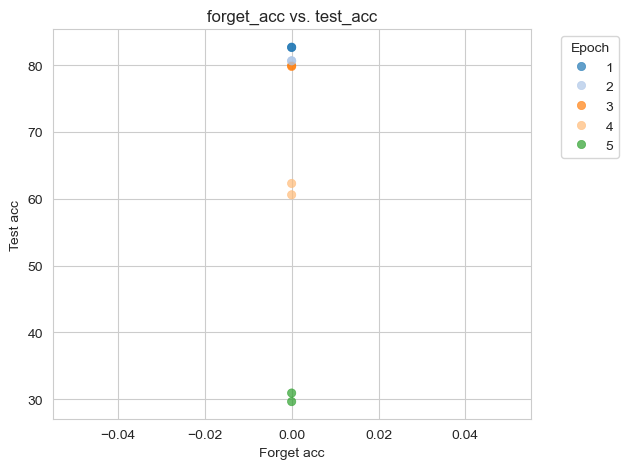

In [9]:
results = gather_results("results/seed_3015", base=False, retrain=False) 
                        #  epochs = [-99, 0, 1, 2, 3, 4, 5, 6])
results_scatterplot(
    results, 
    x_metric = "forget_acc", y_metric = "test_acc", 
    color_by = "epoch"
    )